In [6]:
import pandas as pd

In [7]:
train_df=pd.read_csv('csv/train.csv')

test_df = pd.read_csv('csv/test.csv')

In [8]:
train_df['label'].value_counts()

label
2    752
0    698
1    637
Name: count, dtype: int64

## Prepare data

In [9]:
class_names = {
    0: 'rain',
    1: 'fog',
    2: 'snow'
}

train_df['class_name'] = train_df['label'].map(class_names)
train_df['img_path'] = train_df.apply(
    lambda row: f"3_3_train/train/{class_names[row['label']]}/{row['id']}",
    axis=1
)

In [10]:
from torchvision import transforms, models
from torch.utils.data import Dataset,DataLoader

img_size = 224

train_transform = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=10,translate=(0.1,0.1)),
    transforms.ColorJitter(brightness=0.3,contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
    std = [0.229,0.224,0.225])
])

In [11]:
from sklearn.model_selection import train_test_split

train_data,valid_data = train_test_split(
    train_df,
    test_size =0.2,
    stratify = train_df['label'],
    random_state = 42
)

In [12]:
from PIL import Image

class WeatherDataset(Dataset):
    def __init__(self,df,transform = None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):
        row = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        label = row['label']

        if self.transform :
            image = self.transform(image)

        return image,label

In [13]:
batch_size = 32

train_dataset = WeatherDataset(train_data,transform= train_transform)
valid_dataset = WeatherDataset(valid_data,transform = valid_transform)

train_loader = DataLoader(train_dataset,batch_size = batch_size,shuffle = True,num_workers =0)
valid_loader = DataLoader(valid_dataset,batch_size=batch_size,shuffle= False,num_workers=0)



In [14]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [15]:
def model(num_classes = 3):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features,256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256,num_classes)    
        )

    return model

In [16]:
model = model().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001,weight_decay = 1e-4)
scheduler = ReduceLROnPlateau(optimizer,mode='min',patience= 3,factor=0.5)

In [17]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc='Обучение'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), correct / total

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Валидация'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), correct / total, f1, all_preds, all_labels

print("✅ Функции обучения созданы")

✅ Функции обучения созданы


In [18]:
EPOCHS = 30
best_f1 = 0
patience = 5
counter = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []
val_f1s = []


for epoch in range(EPOCHS):
    print(f"\nЭпоха {epoch+1}/{EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1, val_preds, val_labels = validate(model, valid_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)
    
    scheduler.step(val_loss)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        counter = 0
        torch.save(model.state_dict(), 'best_model_weather.pth')
        print(f" Новая лучшая модель! F1: {best_f1:.4f}")
    else:
        counter += 1
        if counter >= patience:
            print(f" Early stopping на эпохе {epoch+1}")
            break

print(f"\n Лучший F1 на валидации: {best_f1:.4f}")


Эпоха 1/30


Валидация: 100%|██████████| 14/14 [00:23<00:00,  1.69s/it]


Train Loss: 0.3955, Train Acc: 0.8574
Val Loss: 0.3372, Val Acc: 0.9139, Val F1: 0.9127
 Новая лучшая модель! F1: 0.9127

Эпоха 2/30


Валидация: 100%|██████████| 14/14 [00:28<00:00,  2.02s/it]


Train Loss: 0.2445, Train Acc: 0.9155
Val Loss: 0.3039, Val Acc: 0.8971, Val F1: 0.8971

Эпоха 3/30


...

Train Loss: 0.0431, Train Acc: 0.9832
Val Loss: 0.3466, Val Acc: 0.9306, Val F1: 0.9305

Эпоха 15/30


Валидация: 100%|██████████| 14/14 [00:22<00:00,  1.59s/it]


Train Loss: 0.0279, Train Acc: 0.9892
Val Loss: 0.3644, Val Acc: 0.9258, Val F1: 0.9252

Эпоха 16/30


Валидация: 100%|██████████| 14/14 [00:26<00:00,  1.91s/it]


Train Loss: 0.0281, Train Acc: 0.9910
Val Loss: 0.3839, Val Acc: 0.9258, Val F1: 0.9252
 Early stopping на эпохе 16

 Лучший F1 на валидации: 0.9370


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

Валидация: 100%|██████████| 14/14 [00:18<00:00,  1.31s/it]



Финальная точность: 0.9378
Финальный Macro F1: 0.9370

Classification Report:
              precision    recall  f1-score   support

        rain       0.97      0.91      0.94       140
         fog       0.90      0.94      0.92       127
        snow       0.94      0.96      0.95       151

    accuracy                           0.94       418
   macro avg       0.94      0.94      0.94       418
weighted avg       0.94      0.94      0.94       418



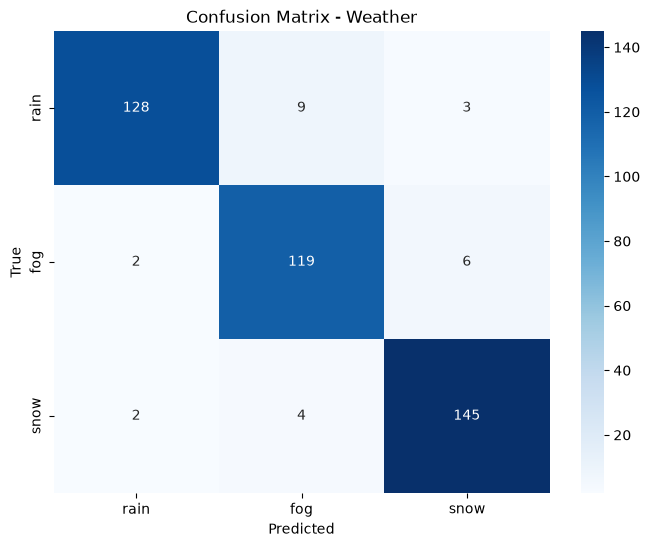

In [20]:
model.load_state_dict(torch.load('best_model_weather.pth'))

_, final_acc, final_f1, final_preds, final_labels = validate(model, valid_loader, criterion)
print(f"\nФинальная точность: {final_acc:.4f}")
print(f"Финальный Macro F1: {final_f1:.4f}")

print("\nClassification Report:")
print(classification_report(final_labels, final_preds, target_names=['rain', 'fog', 'snow']))

cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['rain', 'fog', 'snow'],
            yticklabels=['rain', 'fog', 'snow'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Weather')
plt.show()

In [21]:

def predict_with_tta(model, img_path, n_augmentations=5):
    model.eval()
    predictions = []
    
    tta_transforms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    for _ in range(n_augmentations):
        img = Image.open(img_path).convert('RGB')
        img = tta_transforms(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(img)
            pred = torch.softmax(output, dim=1).cpu().numpy()
            predictions.append(pred)
    
    avg_pred = np.mean(predictions, axis=0)
    return np.argmax(avg_pred), avg_pred

print("✅ TTA функция создана")

✅ TTA функция создана


In [22]:
model.load_state_dict(torch.load('best_model_weather.pth'))

predictions = []
probas = []

for img_id in tqdm(test_df['id'], desc='Предсказание теста'):
    img_path = f"3_3_test_fin/test/{img_id}"
    pred, prob = predict_with_tta(model, img_path, n_augmentations=5)
    predictions.append(pred)
    probas.append(prob)

print("✅ Все предсказания готовы")

Предсказание теста: 100%|██████████| 1431/1431 [11:29<00:00,  2.08it/s]

✅ Все предсказания готовы


In [23]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'label': predictions
})

submission.to_csv('submission_weather.csv', index=False)
print("\n Сабмит сохранён в submission_weather.csv")



 Сабмит сохранён в submission_weather.csv
